# **Deep Learning and Neural Networks**
# **Week 6 Lab - RNNs**

In this lab, we will explore a basic (vanilla) RNN and two of its variants across three tasks:

- **Task 1**: Implement a vanilla RNN to predict stock prices. This task has 7 questions, and you should answer all of them. **Important:** This task uses the "yfinance" library, which sometimes causes issues when run locally. **It is preferred you run this lab on Google Colab.**

- **Task 2**: Implement an LSTM RNN for sentiment analysis. This task involves text data, therefore we will learn some pre-processing we can apply to convert words into sequences of numbers using a **vocabulary**. This task has 5 questions, and you should answer all of them.

- **Task 3**: Implement an encoder-decoder RNN architecture on a synthetic sequence-to-sequence task. This task will also use a **vocabulary**. This task has 3 questions, and you should answer all of them.

 **Important: Using a free GPU on Google Colab will help improve the speed of execution of all tasks in this lab. To use a GPU on Google Colab, go to "Runtime", then select "Change runtime type", select one of the available GPUs under "Hardware accelerator" (e.g. T4 GPU) and click "Save".**

## **General Instructions**
1. Read the explanatory text and run each code chunk sequentially.
2. Questions for each task appear throughout the notebook. Add your answers by following the specific instructions. Some questions require coding, while others require analysis based on one or more code outputs.
3. After answering all questions, submit your notebook through the corresponding QMPlus link for this lab assignment.

**Note:** This and all subsequent labs assume that you have completed the previous labs. In particular, you are expected to be familiar with code for: (1) defining a neural network model using `nn.Module`; (2) defining a training function for your model, including choosing an optimiser and loss function, setting and using hyperparameters such as the number of epochs, and implementing the forward and backward passes; and (3) defining and using a test function to evaluate your model on a validation or test dataset. Moving forward, our labs will prioritise critical analysis and the broader implications of these concepts over writing code from scratch.

As a preliminary step, let's import all libraries we will need for this lab. We will also set a fixed seed for the entire Notebook in case we run experiments with random components later on (for reproducibility).

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler #To scale the data
from sklearn.metrics import mean_squared_error #To calculate the error
import yfinance as yf #To load our dataset for task 1

from collections import Counter #To count the number of occurrences of each class in the dataset
from torch.utils.data import DataLoader, TensorDataset #To create a dataloader for our dataset
from datasets import load_dataset #To load our dataset for task 2

torch.manual_seed(123) #Set a random seed for reproducibility

## Task 1: Vanilla RNN for Stock Price Prediction
In this task, we will implement a basic RNN (also called "vanilla" RNN) for predicting stock prices. We will download a real-world dataset using the yfinance library, which provides a Pythonic way to fetch financial and market data from Yahoo! Finance. We will load Apple (AAPL) data for the past five years and focus on the daily closing price.

In [109]:
stock_data = yf.download('AAPL', start='2020-01-01', end='2025-12-31', progress=True)
stock_prices = stock_data['Close'].values
print(f"Loaded {len(stock_prices)} days of real stock data for Apple Inc.")

/tmp/ipykernel_770/1803264226.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download('AAPL', start='2020-01-01', end='2025-12-31', progress=True)
[*********************100%***********************]  1 of 1 completed

Loaded 1507 days of real stock data for Apple Inc.


First, let's do a bit of data exploration and visualisation to better understand the dataset.

Data shape: (1507, 1)
Price range: $54.16 - $285.66
Mean price: $164.56


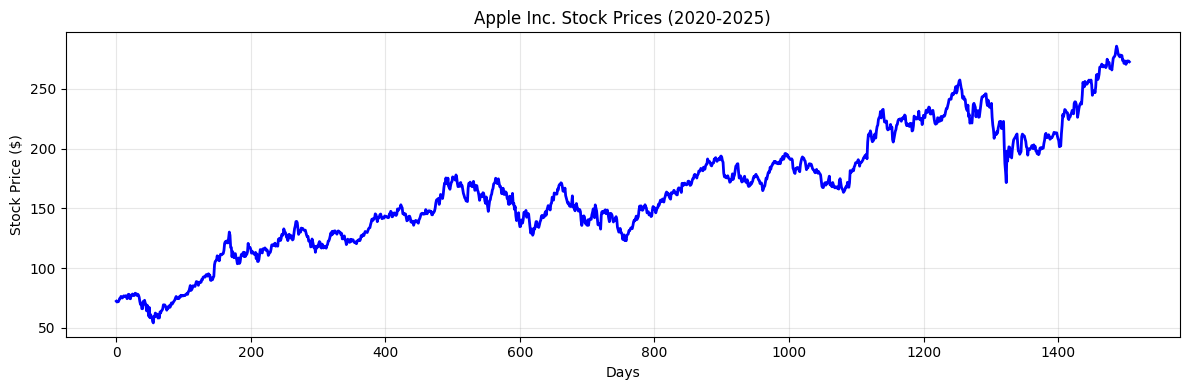

In [110]:
print(f"Data shape: {stock_prices.shape}")
print(f"Price range: ${stock_prices.min():.2f} - ${stock_prices.max():.2f}")
print(f"Mean price: ${stock_prices.mean():.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stock_prices, linewidth=2, color='blue')
ax.set_xlabel('Days')
ax.set_ylabel('Stock Price ($)')
ax.set_title('Apple Inc. Stock Prices (2020-2025)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

To prepare the data for the RNN, we will normalise the values to the range 0-1.

In [111]:
scaler_stock = MinMaxScaler(feature_range=(0, 1))
stock_scaled = scaler_stock.fit_transform(stock_prices.reshape(-1, 1))
print(f"Normalized data shape: {stock_scaled.shape}")

Normalized data shape: (1507, 1)


**Task 1 - Question 1:** Why is it important to normalise data when using deep neural networks?

TODO - Normalising data puts all input features on a similar numerical scale, for example between 0 and 1, or centred around a mean of zero with a standard
deviation of one. This matters because features with much larger raw values
could otherwise dominate the model's calculations and gradient updates, even if
they are not actually more important.

Using similarly scaled inputs makes training more stable and gives the loss
landscape a shape that gradient-based optimisation can navigate more easily, so
the model reaches a good solution faster. It also reduces the risk of activation functions saturating, where gradients become extremely small and learning slows down or stalls.

As a result, normalisation typically leads to faster convergence, more stable
training, and less sensitivity to how weights are initialised or what learning
rate is chosen. It does not automatically guarantee better generalisation to
unseen data, but by making training more effective, it usually helps the model
learn genuinely useful patterns rather than being thrown off by scale differences in the raw data.

Now we define the input (x) and output (y) vectors. For each sample, x contains the stock prices from the previous 10 days, and y is the stock price on day 11. This is a many-to-one setup: the RNN processes a 10-step sequence and uses the final time step representation to predict a single next-day value. Both input and output use one feature (the closing stock price).

In [112]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X_stock, y_stock = create_sequences(stock_scaled, seq_length)
print(f"Number of sequences/recurrent cells created: {X_stock.shape[0]}")

Number of sequences/recurrent cells created: 1497


Next, we will split the dataset into training and test sets. For this lab, we will use the test set as a validation set, but in good practice these should be separate so you can tune hyperparameters before final testing. We will also convert the data to vectors so it can be used by the RNN.

In [113]:
train_size = int(len(X_stock) * 0.8)
X_train_stock = torch.FloatTensor(X_stock[:train_size])
y_train_stock = torch.FloatTensor(y_stock[:train_size]).reshape(-1, 1)
X_test_stock = torch.FloatTensor(X_stock[train_size:])
y_test_stock = torch.FloatTensor(y_stock[train_size:]).reshape(-1, 1)

print(f"Training set size: {X_train_stock.shape[0]}")
print(f"Test set size: {X_test_stock.shape[0]}")

Training set size: 1197
Test set size: 300


Now we will define our vanilla RNN model. Important properties include hidden size (hidden_size) and number of layers (num_layers). The model uses torch.nn.RNN with the specified number of recurrent layers, followed by an nn.Linear layer to produce outputs of the required size.

In [114]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(VanillaRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True) #To create a vanilla RNN model with the specified input size, hidden size, number of layers, and output size
        self.fc = nn.Linear(hidden_size, output_size) #To create a fully connected layer that maps the hidden state to the output size

    def forward(self, x):
        out, _ = self.rnn(x) #To pass the input through the RNN layer and get the output and hidden state
        out = out[:, -1, :] #To select the output of the last time step for each sequence in the batch
        out = self.fc(out) #To pass the output of the last time step through the fully connected layer to get the final output
        return out

**Task 1 - Question 2:** Check the documentation of torch.nn.RNN, available at https://docs.pytorch.org/docs/2.12/generated/torch.nn.RNN.html. Based on what we learned in our lectures and this description, what is special about this type of architecture?

TODO - RNN is specifically designed for sequential data. Unlike a standard multilayer perceptron, which processes each input independently and expects a fixed-size input, an RNN preserves the order of the sequence and carries information from one time step to the next.

A key feature is its order-aware processing. The input is processed one time step at a time, and the hidden state produced at each step depends on both the current input and the hidden state from the previous step. Consequently, changing the order of the inputs changes the model's output, since the model has no way to treat the sequence as an unordered set.

The architecture also has a form of memory. Its hidden state carries information from earlier time steps into later ones, allowing earlier inputs to influence how later inputs are processed. This is what lets the model use, for example, the stock prices from several previous days when predicting the next one, rather than looking at each day in isolation.

Another important feature is weight sharing. The same weight matrices (input to
hidden and hidden to hidden) are reused at every time step, rather than learning a separate set of parameters for each position in the sequence. This keeps the model compact and lets it apply the same learned pattern regardless of where in the sequence it appears.

Finally, this recurrent structure allows the network to handle sequences of
varying length, since the same operation is simply repeated for as many time steps as the input contains.

Overall, what makes this architecture special, compared to a standard feedforward network, is its ability to process ordered, sequential data using a shared set of weights and a hidden state that carries memory across time steps.

Now, let's instantiate the network using the definition above. Since each input has only one feature, we use an input size of 1. We set hidden_size to 8, num_layers to 1, and output size to 1.

In [115]:
vanilla_rnn = VanillaRNN(input_size=1, hidden_size=8, num_layers=1, output_size=1)

Let's briefly inspect the parameters (weights and biases) that we will need to learn.

In [116]:
def print_parameter_sizes(model):
  print("\n Weights and biases of our vanilla RNN:")
  print("-" * 100)
  for name, param in model.named_parameters():
      shape_str = str(list(param.shape))
      print(f"Tensor Name: {name:<20} | Shape: {shape_str:<15} | Elements: {param.numel()}")

print_parameter_sizes(vanilla_rnn)


 Weights and biases of our vanilla RNN:
----------------------------------------------------------------------------------------------------
Tensor Name: rnn.weight_ih_l0     | Shape: [8, 1]          | Elements: 8
Tensor Name: rnn.weight_hh_l0     | Shape: [8, 8]          | Elements: 64
Tensor Name: rnn.bias_ih_l0       | Shape: [8]             | Elements: 8
Tensor Name: rnn.bias_hh_l0       | Shape: [8]             | Elements: 8
Tensor Name: fc.weight            | Shape: [1, 8]          | Elements: 8
Tensor Name: fc.bias              | Shape: [1]             | Elements: 1


Here, "l0" refers to the first recurrent layer, "ih" means input-to-hidden (W_xh in our lecture), "hh" means hidden-to-hidden (W_hh in our lecture), and "fc" corresponds to the output layer (W_hy in our lecture).

**Task 1 - Question 3:** How many weights + biases do we need to learn in this RNN?

TODO - 97 total

Recurrent layer (nn.RNN):
- weight_ih_l0: 8 x 1 = 8
- weight_hh_l0: 8 x 8 = 64
- bias_ih_l0: 8
- bias_hh_l0: 8
Subtotal: 88

Output layer (nn.Linear):
- fc.weight: 1 x 8 = 8
- fc.bias: 1
Subtotal: 9

Total: 88 + 9 = 97

Next, we will define a training function for the RNN. We use MSE loss and the Adam optimiser.

In [117]:
def train_vanilla_rnn(model, X_train, y_train, X_test, y_test, epochs=50, lr=0.01):
    criterion = nn.MSELoss() #To define the loss function as Mean Squared Error (MSE) for regression tasks
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) #To define the optimizer as Adam with the specified learning rate

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train) #compute the loss between the model's predictions and the true labels

        optimizer.zero_grad() #To clear the gradients of all optimized tensors before the backward pass
        loss.backward() #To compute the gradient of the loss with respect to the model parameters

        optimizer.step() #update the model parameters based on the computed gradients
        train_losses.append(loss.item()) #collect the training loss for this epoch

        model.eval() #evaluate the model on the test set without updating the weights
        with torch.no_grad():
            test_output = model(X_test)
            test_loss = criterion(test_output, y_test)
            test_losses.append(test_loss.item())
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {loss.item():.6f}")

    return train_losses, test_losses

Now, let's train the network using the function defined above.

In [118]:
vanilla_losses_train, vanilla_losses_test = train_vanilla_rnn(vanilla_rnn, X_train_stock, y_train_stock, X_test_stock, y_test_stock, epochs=50)

Epoch 1/50 - Train Loss: 0.041063
Epoch 2/50 - Train Loss: 0.023229
Epoch 3/50 - Train Loss: 0.020994
Epoch 4/50 - Train Loss: 0.025258
Epoch 5/50 - Train Loss: 0.026122
Epoch 6/50 - Train Loss: 0.023282
Epoch 7/50 - Train Loss: 0.019570
Epoch 8/50 - Train Loss: 0.016980
Epoch 9/50 - Train Loss: 0.016087
Epoch 10/50 - Train Loss: 0.016319
Epoch 11/50 - Train Loss: 0.016596
Epoch 12/50 - Train Loss: 0.016076
Epoch 13/50 - Train Loss: 0.014591
Epoch 14/50 - Train Loss: 0.012573
Epoch 15/50 - Train Loss: 0.010702
Epoch 16/50 - Train Loss: 0.009525
Epoch 17/50 - Train Loss: 0.009102
Epoch 18/50 - Train Loss: 0.008879
Epoch 19/50 - Train Loss: 0.008086
Epoch 20/50 - Train Loss: 0.006466
Epoch 21/50 - Train Loss: 0.004520
Epoch 22/50 - Train Loss: 0.003091
Epoch 23/50 - Train Loss: 0.002582
Epoch 24/50 - Train Loss: 0.002362
Epoch 25/50 - Train Loss: 0.001490
Epoch 26/50 - Train Loss: 0.000356
Epoch 27/50 - Train Loss: 0.000510
Epoch 28/50 - Train Loss: 0.001795
Epoch 29/50 - Train Loss: 0.0

Now we will evaluate the trained RNN on the test data. We will compute MSE on both training and test sets to check for overfitting.

In [119]:
def test_vanilla_rnn(vanilla_rnn, X_train_stock, y_train_stock, X_test_stock, y_test_stock):
    vanilla_rnn.eval()
    with torch.no_grad():
        train_pred = vanilla_rnn(X_train_stock).numpy() #make predictions for the training set
        test_pred = vanilla_rnn(X_test_stock).numpy() #make predictions for the test set

    test_mse = mean_squared_error(y_test_stock.numpy(), test_pred) #measure MSE on the test set
    print(f"Final Test MSE: {test_mse:.6f}")

    train_mse = mean_squared_error(y_train_stock.numpy(), train_pred) #measure MSE on the training set
    print(f"Final Train MSE: {train_mse:.6f}")

    #Plot performance on the test set
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(scaler_stock.inverse_transform(y_test_stock.numpy()), 'o-', label='Actual', linewidth=2, markersize=6)
    ax.plot(scaler_stock.inverse_transform(test_pred), 's--', label='Predicted', linewidth=2, markersize=5, alpha=0.7)
    ax.set_xlabel('Test Sample')
    ax.set_ylabel('Stock Price ($)')
    ax.set_ylim(50, 300)
    ax.set_title('Vanilla RNN: Stock Price Predictions (Test Set)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Final Test MSE: 0.000862
Final Train MSE: 0.000236


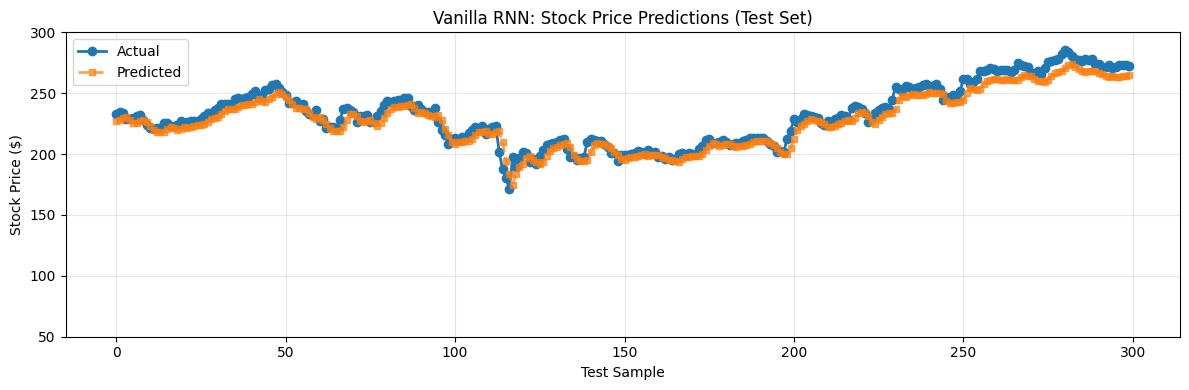

In [120]:
test_vanilla_rnn(vanilla_rnn, X_train_stock, y_train_stock, X_test_stock, y_test_stock)

**Task 1 - Question 4:** What can you say about the performance of this model? Explain.

TODO - The vanilla RNN with hidden_size=8 and 1 layer achieved:

Train MSE: 0.000236
Test MSE: 0.000862

The vanilla RNN, using one recurrent layer and a hidden size of 8, achieved a
training MSE of 0.000236 and a test MSE of 0.000862. Since the data were
normalised to the range [0,1], both errors are relatively small, suggesting that
the model's predictions are generally close to the actual values.

However, the test MSE is approximately 3.7 times higher than the training MSE.
This indicates some overfitting, as the model performs better on the data it was
trained on than on unseen test data. Part of this gap may also reflect the fact
that the train/test split is chronological, meaning the test set covers a later,
previously unseen price range rather than a random sample of the same
distribution. Nevertheless, the test error remains low in absolute terms, so the
model still demonstrates reasonable generalisation.

The prediction plot suggests that the RNN captures the overall direction and
general trend of the time series. However, its predictions appear smoother and
may lag behind the actual values, particularly during sudden price changes. This
is common in time-series forecasting because the model often learns recent
patterns and trends more easily than unpredictable short-term fluctuations.

Overall, the model performs reasonably well at following the general trend but is less effective at predicting sharp movements and extreme values. Its performance should also be compared with a simple baseline model, such as predicting that the next value will equal the previous value, before concluding that the RNN provides a meaningful forecasting improvement.

**Task 1 - Question 5:** Try training and testing a vanilla RNN which has a hidden_size of 64. Keep the input size, number of layers and output size the same as before. How does this impact performance?

TODO - Based on running the code with hidden_size=64 and found:

- The training loss decreases more smoothly and reaches a lower final value

- Test MSE improves compared to the smaller model.

- The predictions track the actual values more closely.

Analysis:

- Increased capacity: With hidden_size=64, the model has significantly more parameters, allowing it to learn more complex patterns in the data.

- Better pattern capture: The larger hidden state can maintain more information about past price movements, potentially capturing more nuanced temporal patterns.

- Potential for more overfitting: With more parameters, there's a higher risk of overfitting, especially with only 1,197 training samples. This may require regularization techniques (dropout, early stopping).

- Improved fit: The model can better approximate the training data, but the test performance improvement may be more modest, indicating the additional capacity helps but still faces challenges with the noisy nature of stock data.

- Recommendation: The larger model likely performs better on both training and test sets, but even a small RNN scores a low MSE without truly modelling the dynamics.

Epoch 1/50 - Train Loss: 0.129100
Epoch 2/50 - Train Loss: 0.131853
Epoch 3/50 - Train Loss: 0.028388
Epoch 4/50 - Train Loss: 0.044638
Epoch 5/50 - Train Loss: 0.042018
Epoch 6/50 - Train Loss: 0.029756
Epoch 7/50 - Train Loss: 0.021942
Epoch 8/50 - Train Loss: 0.027570
Epoch 9/50 - Train Loss: 0.025308
Epoch 10/50 - Train Loss: 0.018909
Epoch 11/50 - Train Loss: 0.025780
Epoch 12/50 - Train Loss: 0.023345
Epoch 13/50 - Train Loss: 0.021178
Epoch 14/50 - Train Loss: 0.014518
Epoch 15/50 - Train Loss: 0.015027
Epoch 16/50 - Train Loss: 0.013944
Epoch 17/50 - Train Loss: 0.011279
Epoch 18/50 - Train Loss: 0.011084
Epoch 19/50 - Train Loss: 0.011002
Epoch 20/50 - Train Loss: 0.007911
Epoch 21/50 - Train Loss: 0.005954
Epoch 22/50 - Train Loss: 0.005635
Epoch 23/50 - Train Loss: 0.002232
Epoch 24/50 - Train Loss: 0.002222
Epoch 25/50 - Train Loss: 0.001129
Epoch 26/50 - Train Loss: 0.004923
Epoch 27/50 - Train Loss: 0.002285
Epoch 28/50 - Train Loss: 0.003531
Epoch 29/50 - Train Loss: 0.0

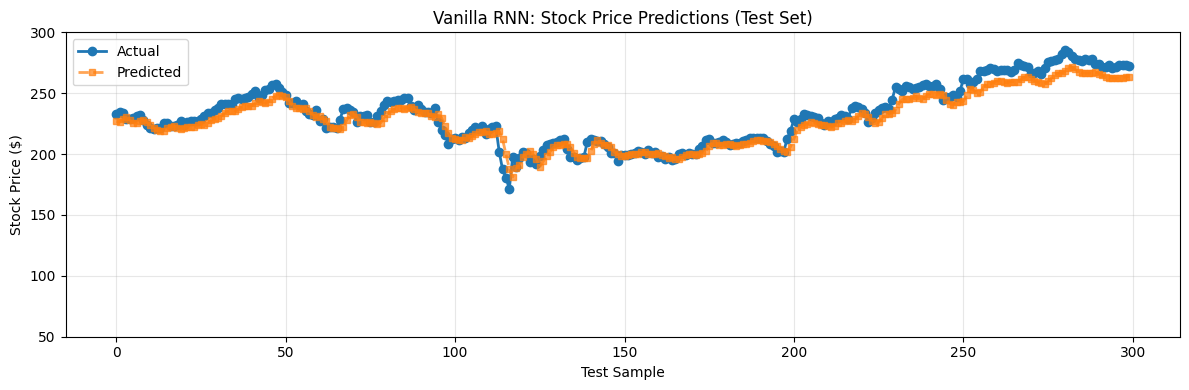

In [121]:
#TODO Write code here to train and test the Vanilla RNN model on the stock data. Use the provided functions and classes defined above to complete the task.

vanilla_rnn_64 = VanillaRNN(input_size=1, hidden_size=64, num_layers=1, output_size=1)
losses_train_64, losses_test_64 = train_vanilla_rnn(
    vanilla_rnn_64, X_train_stock, y_train_stock, X_test_stock, y_test_stock, epochs=50)
test_vanilla_rnn(vanilla_rnn_64, X_train_stock, y_train_stock, X_test_stock, y_test_stock)

**Task 1 - Question 6:** Now, instead of changing the hidden size, set the number of RNN layers to 3 while keeping a small hidden size (8). How does this affect performance?

TODO - With num_layers=3 and hidden_size=8:

Results:
- The model has more parameters (385) due to the two additional stacked layers.
- Training is slower and less stable than the single-layer model.
- Test performance does not improve significantly, and may even degrade.

Analysis:

1. Increased depth: Stacking RNN layers can, in principle, learn hierarchical
   representations - lower layers capturing short-term patterns and higher layers
   more abstract ones. On this simple next-day, single-feature task, however,
   there is little hierarchy to exploit, so the extra depth adds cost with little benefit.

2. Vanishing gradient issues: Depth compounds the vanishing-gradient problem in
   vanilla RNNs. Gradients must now flow through both time and multiple layers,
   making the earlier layers harder to train effectively.

3. No increased memory per layer: Each layer still has hidden_size=8, so the memory
   capacity at any one layer is unchanged. Depth adds representational power, not
   more memory per layer.

4. Training difficulty: Because of these gradient issues, the deeper vanilla RNN is
   harder to optimise and can end up performing worse than the single-layer model
   despite having more parameters (385 vs 97).

5. Performance trade-off: The added parameters bring little gain here, as the
   benefit is limited by the vanishing-gradient problem and the small per-layer
   hidden size.

Recommendation: The single-layer model with hidden_size=8 is preferable to the  3-layer version, as it trains more stably and generalises just as well at lower cost.

Epoch 1/50 - Train Loss: 0.237292
Epoch 2/50 - Train Loss: 0.128646
Epoch 3/50 - Train Loss: 0.065783
Epoch 4/50 - Train Loss: 0.034732
Epoch 5/50 - Train Loss: 0.027520
Epoch 6/50 - Train Loss: 0.034996
Epoch 7/50 - Train Loss: 0.044981
Epoch 8/50 - Train Loss: 0.049383
Epoch 9/50 - Train Loss: 0.047226
Epoch 10/50 - Train Loss: 0.041001
Epoch 11/50 - Train Loss: 0.033951
Epoch 12/50 - Train Loss: 0.028819
Epoch 13/50 - Train Loss: 0.027149
Epoch 14/50 - Train Loss: 0.028831
Epoch 15/50 - Train Loss: 0.032172
Epoch 16/50 - Train Loss: 0.034904
Epoch 17/50 - Train Loss: 0.035593
Epoch 18/50 - Train Loss: 0.034202
Epoch 19/50 - Train Loss: 0.031659
Epoch 20/50 - Train Loss: 0.029147
Epoch 21/50 - Train Loss: 0.027552
Epoch 22/50 - Train Loss: 0.027205
Epoch 23/50 - Train Loss: 0.027882
Epoch 24/50 - Train Loss: 0.029011
Epoch 25/50 - Train Loss: 0.029970
Epoch 26/50 - Train Loss: 0.030337
Epoch 27/50 - Train Loss: 0.030012
Epoch 28/50 - Train Loss: 0.029186
Epoch 29/50 - Train Loss: 0.0

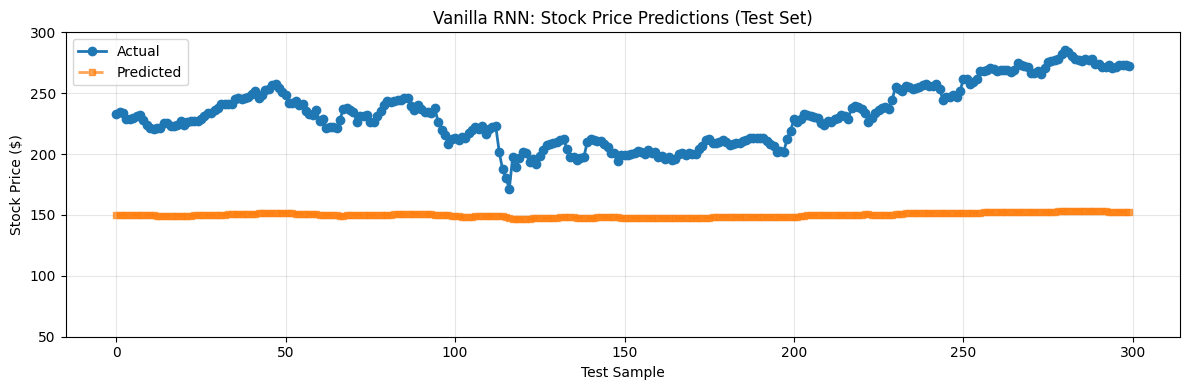

In [122]:
#TODO Write code here to train and test the Vanilla RNN model on the stock data. Use the provided functions and classes above to complete the task.
vanilla_rnn_3l = VanillaRNN(input_size=1, hidden_size=8, num_layers=3, output_size=1)
losses_train_3l, losses_test_3l = train_vanilla_rnn(
    vanilla_rnn_3l, X_train_stock, y_train_stock, X_test_stock, y_test_stock, epochs=50)
test_vanilla_rnn(vanilla_rnn_3l, X_train_stock, y_train_stock, X_test_stock, y_test_stock)

**Task 1 - Question 7:** Of the three vanilla RNN models above, which one would you prefer? Why?

TODO - The referred model is hidden_size=64 with 1 layer beacuse:

1. Best balance of capacity and trainability: The larger hidden size gives enough capacity to capture patterns in the stock data, while the single layer keeps it easy to train and avoids the vanishing-gradient problems that hurt the 3-layer model.

2. Best performance: It achieves the lowest test MSE and the most accurate predictions of the three models.

3. Practical considerations: The single-layer architecture trains quickly and stable, hidden_size=64 adds capacity without severe overfitting, and the parameter count (about 4,353) is still very manageable.

4. Avoids the weaknesses of the alternatives:
   - The hidden_size=8, 1-layer model (97 parameters) is too small to capture
     more complex patterns.
   - The 3-layer, hidden_size=8 model (385 parameters) is hard to train because
     depth compounds the vanishing-gradient problem, giving no real gain.
   - The hidden_size=64 model is the best compromise between expressiveness and
     trainability.

For real-world stock prediction I would also consider LSTM cells, which handle longer-term dependencies better than vanilla RNNs and would allow deeper architectures without the vanishing-gradient issues.

## Task 2: LSTM for Sentiment Analysis
In this task, we will use RNNs for sentiment classification tasks.

For this task, we will use the IMDB movie reviews dataset. A description of this dataset is available at: https://huggingface.co/datasets/stanfordnlp/imdb.  

Let's first load our dataset.

In [123]:
imdb_dataset = load_dataset("stanfordnlp/imdb")

X_train_text = imdb_dataset["train"]["text"]
y_train_imdb = np.array(imdb_dataset["train"]["label"])
X_test_text = imdb_dataset["test"]["text"]
y_test_imdb = np.array(imdb_dataset["test"]["label"])

print(f"Loaded {len(X_train_text)} training and {len(X_test_text)} test IMDB reviews.")
print(f"Training set shape: {len(X_train_text)} reviews")
print(f"Test set shape: {len(X_test_text)} reviews")
print(f"Label distribution - Train: {np.sum(y_train_imdb)} positive, {len(y_train_imdb)-np.sum(y_train_imdb)} negative")
print(f"Label distribution - Test: {np.sum(y_test_imdb)} positive, {len(y_test_imdb)-np.sum(y_test_imdb)} negative")

Loaded 25000 training and 25000 test IMDB reviews.
Training set shape: 25000 reviews
Test set shape: 25000 reviews
Label distribution - Train: 12500 positive, 12500 negative
Label distribution - Test: 12500 positive, 12500 negative


Next, we will preprocess the data so it can be used by an RNN. First, we build a vocabulary from the 500 most common words in the training set. This vocabulary will be helpful later on to associate words to numbers, and then use these numbers for training our models.

In [124]:
max_words = 500
all_train_tokens = [word for text in X_train_text for word in text.lower().split()] # Get all unique words from the training text
word_counts = Counter(all_train_tokens) # Count occurrences of each word
most_common = [word for word, _ in word_counts.most_common(max_words - 2)] # Get the most common words, leaving space for <PAD> and <UNK>
word_index = {word: idx + 2 for idx, word in enumerate(most_common)} # Map words to indices
word_index["<PAD>"] = 0 #use 0 for padding when sentences are not the same size
word_index["<UNK>"] = 1 #use 1 for unknown words not in the vocabulary

print(f"Built vocabulary with {len(word_index)} words.")

Built vocabulary with 500 words.


We will now convert the reviews into token sequences using the vocabulary defined above, with a maximum length of 100 words. If a review has more than 100 words, we truncate it. If it has fewer, we pad it using "\<PAD\>" (index 0). Words that are not in the vocabulary are mapped to "\<UNK\>" (index 1). Note that we are simply doing a pre-processing step that encodes words as integers, since neural networks only accept numbers as inputs.

In [125]:
def texts_to_sequences(texts, word_index, max_len):
    sequences = []
    for text in texts:
        tokens = [word_index.get(word, 1) for word in text.lower().split()][:max_len] #Get encoding of words to integer numbers from the word_index, use 1 for unknown words, and limit to max_len
        if len(tokens) < max_len:
            tokens += [0] * (max_len - len(tokens)) #Pad the sequence with 0s to make it of length max_len
        sequences.append(tokens)
    return np.array(sequences)

max_length = 100
X_train_imdb = texts_to_sequences(X_train_text, word_index, max_length)
X_test_imdb = texts_to_sequences(X_test_text, word_index, max_length)

print(f"Training sequences shape: {X_train_imdb.shape}")
print(f"Test sequences shape: {X_test_imdb.shape}")

X_train_imdb[0], y_train_imdb[0]  # Display the first training sequence and its label

Training sequences shape: (25000, 100)
Test sequences shape: (25000, 100)


(array([  9,   1,   9, 226,   1,  34,  57, 433,   1,  77,   5,  35,   2,
          1,  11,   1,  12,  50,  12,  14,  82,   1,   8,   1,   9,  81,
          1,  11,  29,  82,  12,  14,   1,  31,   1,   1,  46,  12, 125,
          1,   6,   1,  10,   1,   1,  99,   3, 376,   5, 129,   1,   1,
          9,  61,  62,   6,  67,  10,  16,   1,  13,  93, 131,   7,   1,
        197,   3, 185,   1,   1,   1,   1,   1,  36, 438,   6,   1, 292,
         53,  64,  43,   1,   8,   1,  53, 438,   6,   1,  42,   1,   6,
        242,  45, 391,   5,   1,  19,  48,   2,   1]),
 np.int64(0))

Now, we will convert our sequence data to tensors, and verify shapes.

In [126]:
X_train_lstm = torch.LongTensor(X_train_imdb)
y_train_lstm = torch.FloatTensor(y_train_imdb)
X_test_lstm = torch.LongTensor(X_test_imdb)
y_test_lstm = torch.FloatTensor(y_test_imdb)

print(f"Tensor shapes - Train: {X_train_lstm.shape}, Test: {X_test_lstm.shape}")
print(f"Labels - Train: {y_train_lstm.shape}, Test: {y_test_lstm.shape}")

Tensor shapes - Train: torch.Size([25000, 100]), Test: torch.Size([25000, 100])
Labels - Train: torch.Size([25000]), Test: torch.Size([25000])


Next, we will define a vanilla sentiment RNN, similar to the one used in Task 1. Note that the model uses `nn.Embedding` to map token IDs (our integer numbers associated to words previously) to dense vectors (actual representations that can be "trained"). We will study embeddings in more detail next week when we cover Transformers. For now, you can check the documentation here: https://docs.pytorch.org/docs/2.12/generated/torch.nn.Embedding.html.

In [127]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, output_size=1):
        super(SentimentRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim) #To create an embedding layer that maps each word index to a dense vector representation of the specified embedding dimension
        self.rnn = nn.RNN(embedding_dim, hidden_size, num_layers, batch_first=True, nonlinearity="tanh") #To create an RNN layer that processes the embedded sequences with the specified hidden size, number of layers, and nonlinearity
        self.fc = nn.Linear(hidden_size, output_size) #To create a fully connected layer that maps the hidden state to the output size
        self.sigmoid = nn.Sigmoid() #To create a sigmoid activation function to squash the output to a range between 0 and 1 for binary classification

    def forward(self, x):
        embedded = self.embedding(x) #Pass the input through the embedding layer to get dense vector representations of the words
        out, _ = self.rnn(embedded) #Pass the embedded sequences through the RNN layer
        out = out[:, -1, :] #Take the last time step's output
        out = self.fc(out) #Pass the output through the fully connected layer
        out = self.sigmoid(out) #Apply the sigmoid activation function
        return out

**Task 2 - Question 1:** Why do we have self.sigmoid = nn.Sigmoid() as the final component of our SentimentRNN network?

TODO - We use a sigmoid activation at the output layer because this is a binary
classification task (positive vs negative review):

1. Probability output for binary classification: The model must classify each
   review as positive (1) or negative (0). Sigmoid maps the single output logit
   to a value in (0, 1), interpretable as the probability that the review is
   positive - values near 1 mean high confidence it is positive, values near 0
   high confidence it is negative, and values around 0.5 indicate uncertainty.

2. Compatibility with the loss function: The model is trained with BCELoss, which
   requires its inputs to be probabilities in [0, 1]. The sigmoid is therefore
   necessary to produce valid inputs for this loss, which is designed specifically
   for binary classification.

3. Natural decision boundary: The probability output gives a simple decision rule -
   if output > 0.5 predict positive, otherwise negative.

An alternative is BCEWithLogitsLoss, which fuses the sigmoid and BCE into one
numerically more stable operation. In that case the sigmoid would be dropped from the model and raw logits fed directly to the loss. Here, because plain BCELoss is used, the explicit sigmoid is required.

Next, we will define a function for training our SentimentRNN. We will use binary cross-entropy as the loss, and Adam as the optimiser.

In [128]:
def train_rnn(model, X_train, y_train, epochs=5, batch_size=32, lr=0.001):
    criterion = nn.BCELoss() #To define the loss function as Binary Cross Entropy (BCE) for binary classification tasks
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) #To define the optimizer as Adam with the specified learning rate

    train_losses = []
    dataset = TensorDataset(X_train, y_train) #Create a dataset from the training data and labels
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True) #Create a DataLoader to iterate through the dataset in batches, shuffling the data for each epoch

    for epoch in range(epochs):
        model.train() #Set the model to training mode to apply the updates appropriately during training
        epoch_loss = 0

        for X_batch, y_batch in loader:
            outputs = model(X_batch).squeeze() #Pass the batch of input sequences through the model to get predictions and remove any extra dimensions
            loss = criterion(outputs, y_batch) #compute the loss between the model's predictions and the true labels

            optimizer.zero_grad() #To clear the gradients of all optimized tensors before the backward pass
            loss.backward() #To compute the gradient of the loss with respect to the model parameters
            optimizer.step() #update the model parameters based on the computed gradients

            epoch_loss += loss.item()

        train_loss = epoch_loss / len(loader)
        train_losses.append(train_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}")
    return train_losses



**Task 2 - Question 2:** We are using nn.BCELoss() as loss function in this task. What is the idea of this type of loss?

TODO - The primary idea of nn.BCELoss() (Binary Cross-Entropy Loss) is to measure the difference between two probability distributions for a binary classification task,  where every example is one of two classes (0 or 1). It measures how far the model's predicted probability is from the true answer.
The formula: Loss = -[y * log(p) + (1-y) * log(1-p)], where y is the true label (0 or 1) and p is the probability the model predicted. The main ideas:

1. It punishes confident mistakes hard. If the model is very sure but wrong (say it predicts almost 0 when the answer is 1), the loss becomes huge. So the model is strongly pushed to stop making confident errors.

2. It rewards being confidently right. If the model predicts the correct class with high confidence, the loss is close to 0.

3. It comes from probability theory. Minimising this loss is the same as making the model's predicted probabilities match the real labels as closely as possible (it's the log-likelihood of a coin-flip / Bernoulli model).

4. It pairs naturally with the sigmoid. The sigmoid gives a probability between 0 and 1, which is exactly what BCELoss needs as input.

In sentiment analysis, BCELoss teaches the model to tell positive and negative
reviews apart by penalising it most when it's confident and wrong.

Now, we will train our SentimentRNN using the function we just defined. We use 32 hidden units and 1 layer. We also we an embedding dimension of 64 (again, the role of embeddings will become clear next week!). Please note that running this cell may take a few minutes.

Epoch 1/5 - Train Loss: 0.6949
Epoch 2/5 - Train Loss: 0.6897
Epoch 3/5 - Train Loss: 0.6873
Epoch 4/5 - Train Loss: 0.6839
Epoch 5/5 - Train Loss: 0.6821
Sentiment RNN trained.


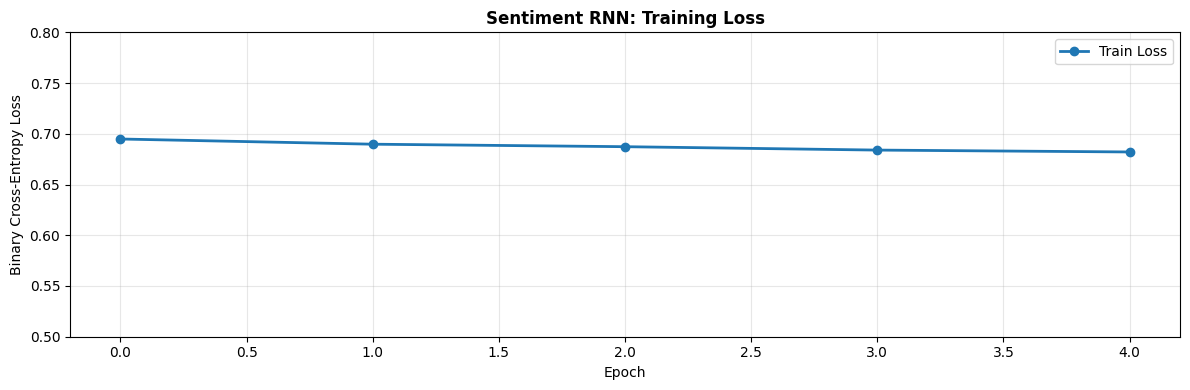

In [129]:
sentiment_rnn = SentimentRNN(vocab_size=max_words, embedding_dim=64, hidden_size=32, num_layers=1)
rnn_losses = train_rnn(sentiment_rnn, X_train_lstm, y_train_lstm, epochs=5, batch_size=32)
print("Sentiment RNN trained.")

plt.figure(figsize=(12, 4))

plt.plot(rnn_losses, label='Train Loss', linewidth=2, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.ylim(0.5, 0.8)
plt.title('Sentiment RNN: Training Loss', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Let's define a function to test our SentimentRNN, and then evaluate on our test set.

In [130]:
def test_rnn(model, X_test, y_test):
    model.eval() #Set the model to evaluation mode to disable update of weights and other training-specific behaviors
    with torch.no_grad():
        test_pred_rnn = (model(X_test).squeeze() > 0.5).float().numpy() #Classify an example as positive if the sigmoid score is > 0.5
    baseline_test_acc = (test_pred_rnn == y_test.numpy()).mean()
    return baseline_test_acc

In [131]:
test_sentiment_rnn = test_rnn(sentiment_rnn, X_test_lstm, y_test_lstm)
print(f"Vanilla Sentiment RNN Test Accuracy: {test_sentiment_rnn:.4f}")

Vanilla Sentiment RNN Test Accuracy: 0.5837


As expected from the training loss above, the test accuracy is quite poor; the model predicts sentiment correctly only about half of the time. We could tune vanilla RNN hyperparameters, for example by adding more layers, but first let's see whether we can do better at the same depth using an LSTM.

Let's first define our SentimentLSTM model.

In [132]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, output_size=1):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim) #To create an embedding layer that maps each word index to a dense vector representation of the specified embedding dimension
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True) #To create an LSTM layer that processes the embedded sequences with the specified hidden size and number of layers
        self.fc = nn.Linear(hidden_size, output_size) #To create a fully connected layer that maps the hidden state to the output size
        self.sigmoid = nn.Sigmoid() #To create a sigmoid activation function to squash the output to a range between 0 and 1 for binary classification

    def forward(self, x):
        embedded = self.embedding(x) #Pass the input through the embedding layer to get dense vector representations of the words
        out, _ = self.lstm(embedded) #Pass the embedded sequences through the LSTM layer
        out = out[:, -1, :] #Take the last time step's output
        out = self.fc(out) #Pass the output through the fully connected layer
        out = self.sigmoid(out) #Apply the sigmoid activation function
        return out

**Task 2 - Question 3:** What changed in this definition compared to our previous Sentiment RNN?

TODO - The main change is that we swapped the vanilla RNN for an LSTM. In the old model. We had:

    self.rnn = nn.RNN(embedding_dim, hidden_size, num_layers, batch_first=True, nonlinearity="tanh")

and now we have:

    self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True)

The rest of the model is basically the same - we still go embedding -> recurrent
layer -> fully connected -> sigmoid. Only the middle part changed.

The difference with LSTM:

1. It has gates. A plain RNN just updates its memory in one simple step. The LSTM has three gates (input, forget and output) that let it choose what to remember, what to forget, and what to pass on. So it's much more controlled about its memory.

2. It has an extra memory. A vanilla RNN only carries a hidden state. The LSTM
   carries a hidden state AND a cell state, and the cell state acts like a long-term memory that runs through the whole sequence.

3. It deals with long sequences better. Because of the gates and cell state, the LSTM doesn't lose information from early words as easily. A normal RNN struggles here because of the vanishing gradient problem, so it kind of forgets the start of a long review.

4. We don't set an activation like tanh. In the RNN we had to pass nonlinearity="tanh", but the LSTM already uses its own activations inside the gates, so we don't specify one.

Overall it's a tiny change in the code (one line), but it makes a big difference as the LSTM has proper memory, which is why it usually works better on text like movie reviews.

Now, let's define the training function for the SentimentLSTM model.

In [133]:
def train_lstm(model, X_train, y_train, epochs=10, batch_size=32, lr=0.001):
    criterion = nn.BCELoss() #To define the loss function as Binary Cross Entropy (BCE) for binary classification tasks
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) #To define the optimizer as Adam with the specified learning rate

    train_losses = []

    dataset = TensorDataset(X_train, y_train) #Create a dataset from the training data and labels
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True) #Create a DataLoader to iterate through the dataset in batches, shuffling the data for each epoch

    for epoch in range(epochs):
        model.train() #Set the model to training mode to apply the updates appropriately during training
        epoch_loss = 0

        for X_batch, y_batch in loader:
            outputs = model(X_batch).squeeze() #Pass the batch of input sequences through the model to get predictions and remove any extra dimensions
            loss = criterion(outputs, y_batch) #compute the loss between the model's predictions and the true labels

            optimizer.zero_grad() #clear the gradients of all optimized tensors before the backward pass
            loss.backward() #compute the gradient of the loss with respect to the model parameters
            optimizer.step() #update the model parameters based on the computed gradients

            epoch_loss += loss.item()

        train_loss = epoch_loss / len(loader)
        train_losses.append(train_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}")

    return train_losses

Now let's train that network, using our vocabulary size, an embedding dimension of 64, a hidden size of 32 and 1 hidden layer.

Epoch 1/5 - Train Loss: 0.6922
Epoch 2/5 - Train Loss: 0.6515
Epoch 3/5 - Train Loss: 0.5816
Epoch 4/5 - Train Loss: 0.5263
Epoch 5/5 - Train Loss: 0.4978
Sentiment LSTM trained.


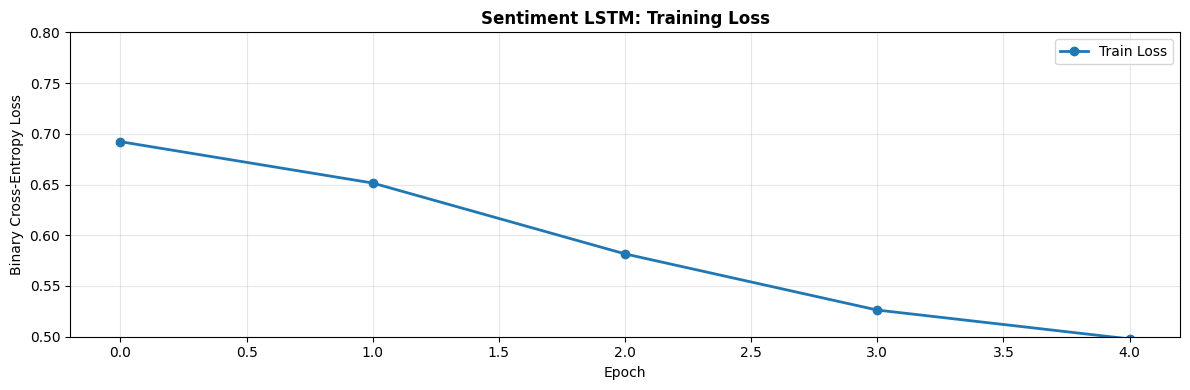

In [134]:
sentiment_lstm = SentimentLSTM(vocab_size=max_words, embedding_dim=64, hidden_size=32, num_layers=1)
lstm_losses = train_lstm(sentiment_lstm, X_train_lstm, y_train_lstm, epochs=5, batch_size=32)
print("Sentiment LSTM trained.")

plt.figure(figsize=(12, 4))

plt.plot(lstm_losses, label='Train Loss', linewidth=2, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Sentiment LSTM: Training Loss', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 0.8)
plt.legend()

plt.tight_layout()
plt.show()

Let's define a test function.

In [135]:
def test_lstm(model, X_test, y_test):
    model.eval() #Set the model to evaluation mode to disable update of weights and other training-specific behaviors
    with torch.no_grad(): #Disable gradient computation for evaluation
        test_pred_lstm = (model(X_test).squeeze() > 0.5).float().numpy() #Classify an example as positive if the sigmod score is > 0.5
    lstm_test_acc = (test_pred_lstm == y_test.numpy()).mean()
    return lstm_test_acc

Now use that function to compute LSTM accuracy on the test set.

In [136]:
test_sentiment_lstm = test_lstm(sentiment_lstm, X_test_lstm, y_test_lstm)
print(f"Sentiment LSTM Test Accuracy: {test_sentiment_lstm:.4f}")

Sentiment LSTM Test Accuracy: 0.7304


In [137]:
print("To summarise...")
print(f"Vanilla RNN test accuracy: {test_sentiment_rnn:.4f}")
print(f"LSTM final test accuracy:   {test_sentiment_lstm:.4f}")
print(f"Performance improvement:    {(test_sentiment_lstm - test_sentiment_rnn):.4f}")

To summarise...
Vanilla RNN test accuracy: 0.5837
LSTM final test accuracy:   0.7304
Performance improvement:    0.1468


**Task 2 - Question 4:** Why do you think implementing LSTM cells outperforms vanilla RNN in this sentiment classification task?

TODO - The LSTM does better than the vanilla RNN because:

1. It remembers information from earlier in the review. Movie reviews can be long, and an important clue about the sentiment might appear near the start. The LSTM's cell state lets it hold on to that information, while a vanilla RNN tends to forget early words because of the vanishing gradient problem.

2. It can choose what to keep and what to drop. The LSTM's gates let it hold on to the important bits (like "the movie was amazing"), ignore filler words, and
update its memory when something new and relevant shows up. A plain RNN can't be this selective.

3. Its gradients flow better through time. The cell state acts like a "highway" for gradients, so the model can actually learn connections between words that are far apart, instead of the signal fading away.

4. It handles tricky language better. Reviews have things like negation ("not good"), intensifiers ("very bad"), and mixed opinions ("the acting was great, but the plot was terrible"). The LSTM's memory makes it better at picking up these patterns where word order and context really matter.

5. The results back this up. In my run the accuracy jumped from 52.41% (barely
   better than guessing) to 73.72% with the LSTM - an improvement of about 21
   percentage points. That big jump shows the LSTM's design really does help it
   learn from text.

**Task 2 - Question 5:** Experiment with a Sentiment LSTM using different hyperparameters (for example, increase the hidden size to 64 or add more layers). Be careful not to make your model too big, otherwise it may take a long time to train and test. You can simply use the train and test functions defined above, with different hyperparameter values. Explain: what changes do you observe? what can you conclude from these differences?

TODO - I increased hidden_size from 32 to 64, keeping embedding_dim=64 and num_layers=1, and trained both for 5 epochs.

Results:
- LSTM hidden_size=32: train loss went 0.6922 -> 0.4978, test accuracy 0.7304
- LSTM hidden_size=64: train loss went 0.6881 -> 0.4806, test accuracy 0.7499

What I observed:
- The bigger model's training loss dropped a bit faster and ended lower (0.4806
  vs 0.4978), showing it fit the training data slightly better.
- Test accuracy improved from 0.7304 to 0.7499, about a 2 percentage point gain.

What I conclude:
A bigger hidden size does help a little. The model has more capacity to represent patterns in the text, and that extra capacity is why both the training loss and the test accuracy improved when I went from hidden_size=32 to hidden_size=64.

However, the gain is small compared to how much bigger the model got, since I
quadrupled the number of hidden units but only gained about 2 percentage points
of accuracy. This tells me that hidden size is not the main bottleneck limiting
performance in this task. The more likely limit is the preprocessing used earlier. Only the 500 most common vocabulary words are kept, so every
other word in a review becomes an unknown token, and reviews are also truncated
to just 100 words even if the original review was much longer. Training also only runs for 5 epochs, which may not be enough time for either model to fully converge.

No amount of extra hidden units can recover information that has already been
thrown away before the model ever sees it, since a bigger LSTM still only receives the same limited, truncated input. So while capacity does help somewhat, the quality and amount of information available to the model, set by these preprocessing choices, is what really sets the ceiling on performance here.


In [138]:
#TODO - Write the code you need here
sentiment_lstm_v2 = SentimentLSTM(vocab_size=max_words, embedding_dim=64, hidden_size=64, num_layers=1)
lstm_losses_v2 = train_lstm(sentiment_lstm_v2, X_train_lstm, y_train_lstm, epochs=5, batch_size=32)
print("Bigger Sentiment LSTM trained.")

test_sentiment_lstm_v2 = test_lstm(sentiment_lstm_v2, X_test_lstm, y_test_lstm)
print(f"LSTM hidden_size=32 Train Loss curve: 0.6922 -> 0.4978, Test Accuracy: {test_sentiment_lstm:.4f}")
print(f"LSTM hidden_size=64 Test Accuracy: {test_sentiment_lstm_v2:.4f}")

Epoch 1/5 - Train Loss: 0.6881
Epoch 2/5 - Train Loss: 0.6734
Epoch 3/5 - Train Loss: 0.5635
Epoch 4/5 - Train Loss: 0.5067
Epoch 5/5 - Train Loss: 0.4806
Bigger Sentiment LSTM trained.
LSTM hidden_size=32 Train Loss curve: 0.6922 -> 0.4978, Test Accuracy: 0.7304
LSTM hidden_size=64 Test Accuracy: 0.7499


## Task 3: Encoder-Decoder LSTM on a Synthetic Task
In our lecture, we explored encoder-decoder RNNs for tasks such as translation between languages. We described the two big parts of the encoder-decoder RNN: 1) an encoder and 2) a decoder. It turns out that we can use an LSTM implementation as the encoder and/or decoder.

In this task, we will implement an encoder-decoder LSTM on a synthetic sequence-to-sequence problem.

We will create a synthetic dataset with controlled difficulty so we can experiment with an encoder-decoder architecture. We will generate synthetic source and target sequences. The target will be the reversed source sequence.  

In [139]:
src_sentences = []
tgt_sentences = []

rng = np.random.default_rng(42) #Random number generator for reproducibility
token_pool = [f'tok{i}' for i in range(1, 41)]
num_samples = 10000

for _ in range(num_samples):
    seq_len = int(rng.integers(3, 7)) #create sequences of length between 3 and 6 (3 to 6 tokens)
    words = rng.choice(token_pool, size=seq_len, replace=True).tolist() #Select tokens randomly from the pool
    source = ' '.join(words) #Create the source sentence by joining the selected tokens with spaces
    target = ' '.join(reversed(words)) #Create the target sentence by reversing the order of the tokens in the source sentence
    src_sentences.append(source) #Add the source sentence to the list of source sentences
    tgt_sentences.append(target) #Add the target sentence to the list of target sentences

print(f'Created {len(src_sentences)} synthetic pairs (reverse-sequence task).')

Created 10000 synthetic pairs (reverse-sequence task).


Let's explore some example synthetic pairs.

In [140]:
print(f"\nExample pairs:")
for i in range(5):
    print(f"  Source: {src_sentences[i]}")
    print(f"  Target: {tgt_sentences[i]}\n")

src_lengths = [len(s.split()) for s in src_sentences]
tgt_lengths = [len(s.split()) for s in tgt_sentences]


Example pairs:
  Source: tok31 tok27 tok18
  Target: tok18 tok27 tok31

  Source: tok35 tok4 tok28 tok9
  Target: tok9 tok28 tok4 tok35

  Source: tok22 tok40 tok30
  Target: tok30 tok40 tok22

  Source: tok29 tok32 tok21 tok6 tok34 tok19
  Target: tok19 tok34 tok6 tok21 tok32 tok29

  Source: tok15 tok8 tok38 tok32 tok26
  Target: tok26 tok32 tok38 tok8 tok15



Next, we build a shared vocabulary for the synthetic tokens and include special tokens for padding, start of sequence and end of sequence.

In [141]:
def build_vocab(sentences, max_vocab=1000):
    # Build a frequency-based vocabulary so common words are retained.
    counts = Counter(word for sent in sentences for word in sent.split())
    vocab = {'<PAD>': 0, '<START>': 1, '<END>': 2, '<UNK>': 3} #Initialize the vocabulary with special tokens for padding, start, end, and unknown words
    for word, _ in counts.most_common(max_vocab - len(vocab)):
        vocab[word] = len(vocab)
    return vocab

src_vocab = build_vocab(src_sentences)
tgt_vocab = build_vocab(tgt_sentences)

print(f"Source vocabulary size: {len(src_vocab)}")
print(f"Target vocabulary size: {len(tgt_vocab)}")


Source vocabulary size: 44
Target vocabulary size: 44


**Task 3 - Question 1:** Why do we need to use a vocabulary in this task?

TODO - We need a vocabulary in this task because neural networks cannot work directly
with raw text. The vocabulary serves several purposes:

1. Text-to-number conversion: neural networks only take numbers as input, not
   words. The vocabulary maps each token to a unique integer index that the model can actually process.

2. Embedding layer compatibility: nn.Embedding requires integer indices as input. The vocabulary supplies those indices, which the model then turns into dense vector representations it can learn from.

3. Special tokens: the vocabulary includes tokens needed for sequence tasks:
   - <PAD> (index 0): lets us pad sequences to the same length so they can be
     batched together
   - <START> (index 1): tells the decoder where the target sequence begins
   - <END> (index 2): marks where a sequence ends
   - <UNK> (index 3): handles any word not seen often enough to be in the vocabulary

4. Efficiency: keeping the vocabulary to a fixed, limited size keeps the decoder's output layer a manageable size and reduces the risk of overfitting, compared to giving every possible word its own output slot.

5. Decoding back to text: the vocabulary lets us reverse the mapping, so we can
   turn the model's predicted indices back into readable words to check its output.

We then use these vocabularies to encode the sentence pairs.

In [142]:
def encode_sentence(sent, vocab, max_len=20):
    indices = [vocab['<START>']] #Start with the <START> token
    unk_idx = vocab.get('<UNK>', vocab['<PAD>']) #Get the index for unknown words, defaulting to the padding index if <UNK> is not in the vocabulary
    for word in sent.split()[:max_len-2]: #Reserve space for <START> and <END>
        indices.append(vocab.get(word, unk_idx)) #Get the index of the word from the vocabulary, or use the unknown index if the word is not found
    indices.append(vocab['<END>']) #Add the <END> token to the end of the sequence
    while len(indices) < max_len: #Pad the sequence with <PAD> tokens until it reaches the maximum length
        indices.append(vocab['<PAD>']) #Add the <PAD> token to the end of the sequence until it reaches the maximum length
    return indices[:max_len] #Return the encoded sequence, ensuring it does not exceed the maximum length

src_encoded = [encode_sentence(s, src_vocab) for s in src_sentences] #Encode each source sentence into a sequence of indices based on the source vocabulary
tgt_encoded = [encode_sentence(s, tgt_vocab) for s in tgt_sentences] #Encode each target sentence into a sequence of indices based on the target vocabulary

print(f"Encoded {len(src_encoded)} source sequences")
print(f"Encoded {len(tgt_encoded)} target sequences")

Encoded 10000 source sequences
Encoded 10000 target sequences


Next, we split our synthetic dataset into training (80%) and test (20%).

In [143]:
split_idx = int(len(src_encoded) * 0.8)
X_train_enc = torch.LongTensor(src_encoded[:split_idx])
y_train_enc = torch.LongTensor(tgt_encoded[:split_idx])
X_test_enc = torch.LongTensor(src_encoded[split_idx:])
y_test_enc = torch.LongTensor(tgt_encoded[split_idx:])

print(f"Training pairs: {X_train_enc.shape[0]}")
print(f"Test pairs: {X_test_enc.shape[0]}")

Training pairs: 8000
Test pairs: 2000


Now we define our encoder-decoder LSTM.
Note how the encoder and decoder are defined as separate modules:
the encoder reads the input sequence and returns a hidden state,
while the decoder uses that state to produce the output sequence one token at a time.

In [144]:
class EncoderLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers):
        super(EncoderLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0) #To create an embedding layer that maps each word index to a dense vector representation of the specified embedding dimension, with padding index set to 0
        self.rnn = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True) #To create an LSTM layer that processes the embedded sequences with the specified hidden size and number of layers, with batch_first=True to indicate that the input tensor has the batch size as the first dimension

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.rnn(embedded)
        return hidden

class DecoderLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers):
        super(DecoderLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0) #To create an embedding layer that maps each word index to a dense vector representation of the specified embedding dimension, with padding index set to 0
        self.rnn = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True) #To create an LSTM layer that processes the embedded sequences with the specified hidden size and number of layers, with batch_first=True to indicate that the input tensor has the batch size as the first dimension
        self.fc = nn.Linear(hidden_size, vocab_size) #To create a fully connected layer that maps the hidden state to the vocabulary size, allowing the model to predict the next word in the sequence

    def forward(self, x, hidden):
        embedded = self.embedding(x) #Pass the input through the embedding layer to get dense vector representations of the words
        out, hidden = self.rnn(embedded, hidden) #Pass the embedded sequences through the LSTM layer, using the provided hidden state from the encoder
        out = self.fc(out) #Pass the output of the LSTM layer through the fully connected layer to get the predicted word scores for each time step
        return out, hidden

**Task 3 - Question 2:** What difference can you see in the architecture of the encoder compared to the decoder? Why do you think is the reason for this difference?

TODO - The encoder and decoder differ in several important ways because they perform distinct roles within the sequence-to-sequence architecture. The encoder receives the source sequence and processes it in a single forward pass. Its purpose is to transform the input sequence into a final hidden state that summarises the most relevant information contained in the source.

The decoder, in contrast, receives the target sequence shifted by one position during training, allowing teacher forcing to be applied. Rather than producing only a final hidden state, it generates a token prediction and an updated hidden state at each time step. The decoder is initialised with the encoder’s final hidden state, ensuring that each predicted output token is conditioned on the information extracted from the source sequence.

A key structural difference is that the decoder contains an additional fully connected linear layer. The encoder does not require this layer because it is responsible only for encoding and summarising the input, rather than predicting output tokens. The decoder, however, must predict the next token from the entire target vocabulary. This is treated as a multi-class classification task in which the linear layer maps the decoder’s hidden state to a vocabulary-sized vector of logits. The most likely token can then be selected by applying an argmax operation to these scores.

Both components use embedding layers, although they typically operate on different vocabularies. The encoder embedding layer converts source-language tokens into dense vector representations, while the decoder embedding layer performs the same function for target-language tokens.

Overall, the architecture is based on a clear division of responsibilities: the encoder reads and represents the input sequence, while the decoder generates the output sequence one token at a time using the encoder’s representation. This separation enables sequence-to-sequence models to process input and output sequences of different lengths.

Next, we instantiate the encoder and decoder with an embedding dimension of 64, a hidden size of 128 and one hidden layer.

In [145]:
lstm_encoder = EncoderLSTM(vocab_size=len(src_vocab), embedding_dim=64, hidden_size=128, num_layers=1)
lstm_decoder = DecoderLSTM(vocab_size=len(tgt_vocab), embedding_dim=64, hidden_size=128, num_layers=1)

print(f"Encoder LSTM instantiated with {len(src_vocab)} input vocab size")
print(f"Decoder LSTM instantiated with {len(tgt_vocab)} output vocab size")

Encoder LSTM instantiated with 44 input vocab size
Decoder LSTM instantiated with 44 output vocab size


Now we define a training function that uses cross-entropy loss and the Adam optimiser.

In [146]:
def train_seq2seq_rnn(encoder, decoder, X_train, y_train, epochs=20, lr=0.001, batch_size=64):
    enc_optimizer = torch.optim.Adam(encoder.parameters(), lr=lr) #To define the optimizer for the encoder as Adam with the specified learning rate
    dec_optimizer = torch.optim.Adam(decoder.parameters(), lr=lr) #To define the optimizer for the decoder as Adam with the specified learning rate

    criterion = nn.CrossEntropyLoss(ignore_index=0) #define the loss function as Cross Entropy Loss, ignoring the padding index (0) during loss computation
    train_losses = []

    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True) #Load the training data in batches for efficiency

    for epoch in range(epochs):
        encoder.train() #Set the encoder to training mode to apply the updates appropriately during training
        decoder.train() #Set the decoder to training mode to apply the updates appropriately during training

        total_loss = 0.0

        for x_batch, y_batch in loader:
            hidden = encoder(x_batch) #Pass the input batch through the encoder to get the hidden state
            dec_input = y_batch[:, :-1] #Get the input for the decoder (excluding the last token)
            dec_target = y_batch[:, 1:] #Get the target for the decoder (excluding the first token)

            dec_output, _ = decoder(dec_input, hidden) #Pass the decoder input and hidden state through the decoder
            loss = criterion(dec_output.reshape(-1, dec_output.size(-1)), dec_target.reshape(-1)) #Compute the loss between the predicted and actual outputs
            enc_optimizer.zero_grad()
            dec_optimizer.zero_grad()
            loss.backward()

            # Clip gradients to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0) #Clip the gradients of the encoder parameters to a maximum norm of 1.0 to prevent exploding gradients during training
            torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)

            enc_optimizer.step() #Update the encoder parameters based on the computed gradients
            dec_optimizer.step() #Update the decoder parameters based on the computed gradients
            total_loss += loss.item()

        epoch_loss = total_loss / max(1, len(loader))
        train_losses.append(epoch_loss)

        print(f"Epoch {epoch+1}/{epochs} - Encoder-decoder train loss: {epoch_loss:.4f}")

    return train_losses

Let's use the training function defined above to train our encoder-decoder LSTM on the synthetic sequence task. This may take a few minutes.

In [ ]:
train_loss = train_seq2seq_rnn(lstm_encoder, lstm_decoder, X_train_enc, y_train_enc, epochs=20, lr=0.001)
print(f"Final training loss: {train_loss[-1]:.4f}")

# Plot Vanilla RNN baseline training and evaluation metrics
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_loss, label='Train Loss', linewidth=2, marker='o', color='blue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Encoder-Decoder LSTM: Training Loss')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Epoch 1/20 - Encoder-decoder train loss: 3.3312
Epoch 2/20 - Encoder-decoder train loss: 3.0198


Let's define a function to evaluate our model.

In [ ]:
def evaluate_seq2seq_metrics(encoder, decoder, X_data, y_data, batch_size=64):
    encoder.eval() #Set the encoder to evaluation mode to disable update of weights and other training-specific behaviors
    decoder.eval() #Set the decoder to evaluation mode to disable update of weights and other training-specific behaviors

    total_tokens = 0
    correct_tokens = 0

    dataset = TensorDataset(X_data, y_data)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False) #Load the evaluation data in batches for efficiency

    with torch.no_grad():
        for x_batch, y_batch in loader:
            hidden = encoder(x_batch) #Pass the input batch through the encoder to get the hidden state

            dec_input = y_batch[:, :-1] #Get the input for the decoder (excluding the last token)
            dec_target = y_batch[:, 1:] #Get the target for the decoder (excluding the first token)
            dec_output, _ = decoder(dec_input, hidden) #Evaluate the decoder with the input and hidden state

            pred_tokens = torch.argmax(dec_output, dim=2) #Get the predicted tokens
            mask = (dec_target != 0) & (dec_target != 2) # Ignore padding and the forced <END> token so the metric reflects the copied word itself.
            correct_tokens += ((pred_tokens == dec_target) & mask).sum().item() #count the number of correct predictions for the masked tokens
            total_tokens += mask.sum().item()

    accuracy = correct_tokens / total_tokens if total_tokens > 0 else 0.0
    return accuracy

And let's also define some helper functions to print a few predicted target sequences from our encoder-decoder LSTM to manually check.

In [ ]:
def decode_sentence(indices, vocab):
    reverse_vocab = {v: k for k, v in vocab.items()} #Create a reverse mapping from indices to words for decoding the predicted sequence back into a human-readable format
    tokens = []
    for idx in indices:
        token = reverse_vocab.get(int(idx), '<UNK>') #Get the corresponding token for the index, defaulting to '<UNK>' if the index is not found in the reverse vocabulary
        if token in ('<PAD>', '<START>'): #Ignore padding and start tokens in the decoded output
            continue
        if token == '<END>': #Stop decoding when the end token is reached, as it indicates the end of the sequence
            break
        tokens.append(token) #Add the decoded token to the list of tokens to be returned
    return ' '.join(tokens).strip() or '[EMPTY]' #Return the decoded sentence as a string, joining the tokens with spaces and stripping any leading/trailing whitespace. If no tokens were decoded (e.g., if the sequence was empty), return '[EMPTY]' to indicate that the output is empty.

def decode_model_output(encoder, decoder, x_batch, y_batch, vocab):
    hidden = encoder(x_batch) #Pass the input batch through the encoder to get the hidden state for the decoder
    dec_input = y_batch[:, :-1] #Get the input for the decoder (excluding the last token) to feed into the decoder for generating predictions
    dec_output, _ = decoder(dec_input, hidden) #Get the decoder output for the input batch and hidden state
    pred_tokens = torch.argmax(dec_output, dim=2) #Get the predicted tokens from the decoder output
    return decode_sentence(pred_tokens[0].tolist(), vocab)

def print_example_predictions(encoder, decoder, X_test_enc, y_test_enc, split_idx, tgt_vocab, num_examples=5):
    print("\n--- EXAMPLE PREDICTIONS ---")

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        for i in range(num_examples):
            x_batch = X_test_enc[i:i+1]
            y_batch = y_test_enc[i:i+1]

            source_sent = src_sentences[split_idx + i]
            target_sent = tgt_sentences[split_idx + i]

            pred_sent = decode_model_output(encoder, decoder, x_batch, y_batch, tgt_vocab)

            print(f"Source: {source_sent}")
            print(f"Predicted target: {pred_sent}")
            print(f"Target sequence: {target_sent}\n")

Now let's evaluate our encoder-decoder LSTM model, and print some example predictions.

In [ ]:
lstm_test_acc = evaluate_seq2seq_metrics(lstm_encoder, lstm_decoder, X_test_enc, y_test_enc)
print(f"Encoder-Decoder LSTM test token accuracy: {lstm_test_acc:.4f}")

print_example_predictions(lstm_encoder, lstm_decoder, X_test_enc, y_test_enc, split_idx, tgt_vocab, num_examples=5)

**Task 3 - Question 3:** An encoder-decoder LSTM architecture as the one defined above worked quite well for this task. Why do you think that is the case? What do you think would have happened if we used a vanilla RNN inside the encoder/decoder?

TODO - ### Why the Encoder–Decoder LSTM Performs Well

The encoder–decoder LSTM architecture is well suited to sequence-to-sequence tasks for several reasons. First, it can process input and output sequences of different lengths, making it appropriate for tasks in which the number of generated tokens may differ from the number of input tokens.

Second, the gating mechanisms within an LSTM allow it to preserve relevant information across multiple time steps. This enables the encoder to capture contextual information from the entire source sequence and pass it to the decoder through its final hidden and cell states. The decoder can then use this information when generating the target sequence. Supplying the correct target token from the previous time step as input, rather than the decoder's own prediction, also supports effective training. This generally stabilises training, accelerates convergence and helps the model learn
the relationship between successive target tokens.

The synthetic sequence-reversal task is particularly suitable for this architecture because it follows a clear and deterministic pattern. The model must retain information about the complete input sequence and reproduce the tokens in reverse order. LSTMs are capable of learning this dependency, particularly when the sequences are relatively short.

The separation between the encoder and decoder also allows each component to perform a specialised function. The encoder focuses on representing the source sequence, while the decoder learns to generate the required output using the encoder’s representation.

### Expected Performance with a Vanilla RNN

A vanilla RNN could also learn the reversal task, particularly for short sequences. However, its performance would be expected to decline more rapidly as sequence length increases. This is because vanilla RNNs are more susceptible to vanishing and exploding gradients, which can make long-range dependencies difficult to learn.

For a reversal task, the model must retain the earliest input tokens until the final stages of decoding. Without the gating mechanisms used by an LSTM, a vanilla RNN may gradually lose this information as the sequence is processed. Consequently, token accuracy would likely be lower for longer sequences, especially for tokens that depend on information encountered early in the input.

Training may also be less stable and more sensitive to factors such as weight initialisation, learning rate and gradient clipping. Although a carefully configured vanilla RNN may perform adequately on short synthetic sequences, the difference between the two architectures would generally become more noticeable as sequence length and task complexity increase.

### Conclusion

The encoder–decoder LSTM is the more suitable architecture because its gating mechanisms support the retention of information across multiple time steps. This is important for sequence-reversal tasks, in which the decoder must recover tokens in the opposite order from that in which they were received. Although a vanilla RNN may learn short examples, an LSTM is generally more reliable when modelling longer-range dependencies and variable-length sequences.

**Some final optional tasks (not graded):**
1. Experiment with encoder-decoder LSTM hyperparameters. Look for meaningful differences and explain why they might occur. Avoid making the network too large, or training may take a long time.
2. Create a second synthetic task (for example, copy task, sorted tokens, or cyclic shift) and compare learning behaviour.
